# Mission 16 Inference

이 노트북은 `modeling.ipynb`에서 저장한 세 모델 파일을 다시 불러와 추론이 가능한지 검증합니다.

- 기본 PyTorch 모델
- 양자화 PyTorch 모델
- ONNX 모델

이 노트북이 필요한 이유는 저장 파일이 실제로 다시 사용할 수 있는지 확인하기 위해서입니다. 모델을 저장하는 것만으로는 충분하지 않습니다. 제출 전에는 반드시 “저장한 파일을 다시 불러와 예측할 수 있는지” 확인해야 합니다.


## 1. 환경과 모델 파일 확인

이 셀은 추론에 필요한 모델 파일 3개가 실제로 존재하는지 확인하는 단계입니다.

`inference.ipynb`에서는 학습을 다시 하지 않습니다. 이미 만들어진 `.pth`, 양자화 `.pth`, `.onnx` 파일만 사용해야 하므로, 파일 경로와 파일 존재 여부를 먼저 검증합니다.


In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import onnxruntime as ort
import matplotlib.pyplot as plt

# 제출 폴더를 기준으로 모델 파일과 보고서 자료 위치를 잡습니다.
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "mission-result" / "models"
DATA_DIR = BASE_DIR / "mission-result" / "data"
REPORT_ASSETS_DIR = BASE_DIR / "report-assets"
REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# modeling.ipynb에서 생성한 세 모델 파일 경로입니다.
BASE_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp.pth"
QUANTIZED_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp_quantized.pth"
ONNX_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp.onnx"

# 추론 노트북은 저장된 모델 파일을 쓰는 것이 목적이므로 파일 존재 여부를 먼저 확인합니다.
for path in [BASE_MODEL_PATH, QUANTIZED_MODEL_PATH, ONNX_MODEL_PATH]:
    print(path.name, "exists=", path.exists(), "bytes=", path.stat().st_size if path.exists() else None)
    assert path.exists(), f"Missing model file: {path}"

print("torch:", torch.__version__)
print("onnxruntime:", ort.__version__)


mission_16_mnist_mlp.pth exists= True bytes= 2145928
mission_16_mnist_mlp_quantized.pth exists= True bytes= 542962
mission_16_mnist_mlp.onnx exists= True bytes= 2144478
torch: 2.5.1+cu121
onnxruntime: 1.25.1


## 2. 모델 구조와 데이터 준비

이 셀은 저장된 `.pth` 파일을 다시 읽기 위한 모델 구조와 테스트 데이터를 준비하는 단계입니다.

PyTorch의 `state_dict` 방식은 가중치만 저장합니다. 그래서 저장된 가중치를 로드하려면 학습 때 사용했던 것과 같은 `MNISTMLP` 구조가 필요합니다.

테스트 데이터는 세 모델을 같은 기준으로 비교하기 위해 사용합니다.


In [2]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.classifier(x)

# 학습 때와 같은 전처리를 사용해야 저장된 모델의 예측이 일관됩니다.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# 추론 검증에는 테스트 데이터만 사용합니다. 여기서는 학습을 다시 하지 않습니다.
test_dataset = datasets.MNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

print("test samples:", len(test_dataset))


test samples: 10000


## 3. 기본 PyTorch 모델 로드와 평가

이 셀은 기본 `.pth` 파일이 정상적으로 다시 불러와지는지 확인하는 단계입니다.

여기서 성공해야 `mission_16_mnist_mlp.pth`가 단순히 파일로 존재하는 것뿐 아니라 실제 추론 가능한 모델 파일이라는 것을 보여줄 수 있습니다.


In [3]:
def evaluate_torch(model_to_eval, loader):
    model_to_eval.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            logits = model_to_eval(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# 기본 PyTorch 모델은 같은 모델 구조를 만든 뒤 저장된 state_dict를 로드합니다.
base_checkpoint = torch.load(BASE_MODEL_PATH, map_location="cpu", weights_only=False)
base_model = MNISTMLP().eval()
base_model.load_state_dict(base_checkpoint["model_state_dict"])

# 재로드된 모델이 실제로 추론 가능한지 정확도를 계산합니다.
base_accuracy = evaluate_torch(base_model, test_loader)
print("base_accuracy:", base_accuracy)


base_accuracy: 0.9762


## 4. 양자화 PyTorch 모델 로드와 평가

이 셀은 양자화된 `.pth` 파일을 다시 불러와 추론하는 단계입니다.

양자화 모델은 기본 모델과 내부 계층 타입이 달라집니다. 그래서 먼저 같은 MLP 구조에 동적 양자화를 적용해 양자화 모델 구조를 만든 뒤, 저장된 양자화 가중치를 로드합니다.

이 과정을 통해 “용량을 줄인 모델도 실제로 예측에 사용할 수 있는지” 확인합니다.


In [4]:
quant_checkpoint = torch.load(QUANTIZED_MODEL_PATH, map_location="cpu", weights_only=False)

# 양자화 모델을 로드하려면 먼저 같은 방식으로 동적 양자화된 모델 구조를 만들어야 합니다.
quantized_model = torch.quantization.quantize_dynamic(
    MNISTMLP().eval(),
    {nn.Linear},
    dtype=torch.qint8,
).eval()

# 저장된 양자화 가중치를 로드하고 정확도를 확인합니다.
quantized_model.load_state_dict(quant_checkpoint["model_state_dict"])
quantized_accuracy = evaluate_torch(quantized_model, test_loader)
print("quantized_accuracy:", quantized_accuracy)


C:\Users\amy\AppData\Roaming\Python\Python311\site-packages\torch\_utils.py:392: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


quantized_accuracy: 0.9761


## 5. ONNX 모델 로드와 평가

이 셀은 ONNX 모델을 PyTorch가 아니라 ONNX Runtime으로 실행하는 단계입니다.

ONNX를 쓰는 이유는 PyTorch 밖의 환경에서도 모델을 실행하기 위해서입니다. 즉, Python/PyTorch 학습 환경과 실제 배포 환경이 다를 때 ONNX가 중간 교환 형식 역할을 합니다.

여기서 ONNX Runtime 추론이 성공하면, 변환된 `.onnx` 파일이 실제 실행 가능한 모델이라는 것을 확인할 수 있습니다.


In [5]:
def evaluate_onnx(onnx_path, loader):
    # ONNX Runtime은 ONNX 파일을 직접 실행합니다.
    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    correct = 0
    total = 0

    for x, y in loader:
        # PyTorch Tensor를 ONNX Runtime이 받을 수 있는 numpy float32 배열로 변환합니다.
        logits = session.run([output_name], {input_name: x.numpy().astype(np.float32)})[0]
        pred = logits.argmax(axis=1)
        correct += int((pred == y.numpy()).sum())
        total += len(y)

    return correct / total

# 샘플 예측 비교에서도 재사용할 ONNX 세션입니다.
onnx_session = ort.InferenceSession(str(ONNX_MODEL_PATH), providers=["CPUExecutionProvider"])
onnx_input_name = onnx_session.get_inputs()[0].name
onnx_output_name = onnx_session.get_outputs()[0].name
onnx_accuracy = evaluate_onnx(ONNX_MODEL_PATH, test_loader)
print("onnx_accuracy:", onnx_accuracy)
print("onnx input:", onnx_input_name)
print("onnx output:", onnx_output_name)


onnx_accuracy: 0.9762
onnx input: input
onnx output: logits


## 6. 같은 샘플에 대한 세 모델 예측 비교

이 셀은 같은 입력 이미지를 세 모델에 넣고 예측 결과를 나란히 비교하는 단계입니다.

전체 정확도도 중요하지만, 같은 샘플에 대해 기본 모델, 양자화 모델, ONNX 모델이 비슷한 예측을 내는지 보는 것도 중요합니다. 이 비교는 보고서에서 변환 결과가 정상이라는 근거로 사용할 수 있습니다.


In [6]:
sample_count = 12

# 테스트 데이터 앞쪽 12개를 샘플로 사용해 세 모델의 예측을 비교합니다.
sample_images = torch.stack([test_dataset[i][0] for i in range(sample_count)], dim=0)
sample_labels = torch.tensor([test_dataset[i][1] for i in range(sample_count)])

with torch.no_grad():
    base_pred = base_model(sample_images).argmax(dim=1).numpy()
    quant_pred = quantized_model(sample_images).argmax(dim=1).numpy()

# ONNX 모델은 ONNX Runtime 세션에 numpy 입력을 넣어 예측합니다.
onnx_logits = onnx_session.run(
    [onnx_output_name],
    {onnx_input_name: sample_images.numpy().astype(np.float32)},
)[0]
onnx_pred = onnx_logits.argmax(axis=1)

# 세 모델의 예측을 표로 정리합니다.
sample_df = pd.DataFrame({
    "index": list(range(sample_count)),
    "true_label": sample_labels.numpy(),
    "base_pth_pred": base_pred,
    "quantized_pth_pred": quant_pred,
    "onnx_pred": onnx_pred,
})

display(sample_df)
sample_csv = REPORT_ASSETS_DIR / "mission16_inference_sample_predictions.csv"
sample_df.to_csv(sample_csv, index=False, encoding="utf-8-sig")
print("saved sample predictions:", sample_csv)


,index,true_label,base_pth_pred,quantized_pth_pred,onnx_pred
0,0,7,7,7,7
1,1,2,2,2,2
2,2,1,1,1,1
3,3,0,0,0,0
4,4,4,4,4,4
5,5,1,1,1,1
6,6,4,4,4,4
7,7,9,9,9,9
8,8,5,5,5,5
9,9,9,9,9,9


saved sample predictions: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_inference_sample_predictions.csv


saved sample image: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_inference_sample_predictions.png


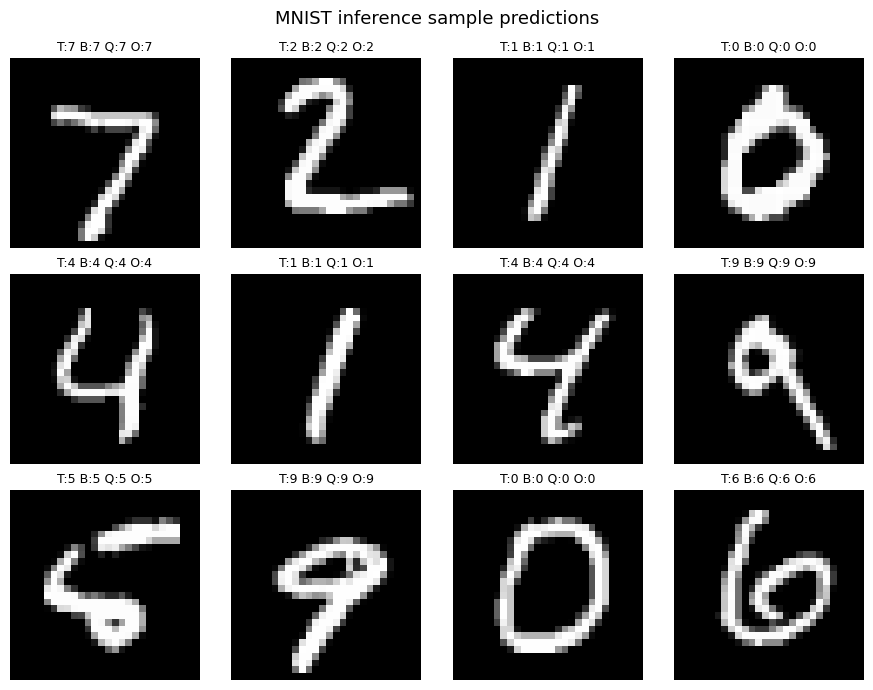

In [7]:
def unnormalize_mnist(x):
    # 보고서 이미지로 볼 때는 정규화된 값을 원래 픽셀 범위에 가깝게 되돌립니다.
    return x.squeeze(0).numpy() * 0.3081 + 0.1307

# 샘플 이미지와 세 모델의 예측 결과를 한 화면에 저장합니다.
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for idx, ax in enumerate(axes.ravel()):
    image = unnormalize_mnist(sample_images[idx])
    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"T:{sample_labels[idx].item()} B:{base_pred[idx]} Q:{quant_pred[idx]} O:{onnx_pred[idx]}",
        fontsize=9,
    )

fig.suptitle("MNIST inference sample predictions", fontsize=13)
fig.tight_layout()
sample_png = REPORT_ASSETS_DIR / "mission16_inference_sample_predictions.png"
fig.savefig(sample_png, dpi=180, bbox_inches="tight")
print("saved sample image:", sample_png)
plt.show()


## 7. 추론 결과 요약 저장

이 셀은 추론 검증 결과를 보고서 자료로 남기는 단계입니다.

정확도, 샘플 예측 결과 CSV, 샘플 이미지 캡처 경로를 JSON으로 저장해두면 나중에 결과를 다시 확인하거나 보고서에 옮기기 쉽습니다.


In [8]:
# 추론 검증 결과를 JSON으로 저장합니다.
summary = {
    "base_pth_accuracy": base_accuracy,
    "quantized_pth_accuracy": quantized_accuracy,
    "onnx_accuracy": onnx_accuracy,
    "sample_predictions_csv": str((REPORT_ASSETS_DIR / "mission16_inference_sample_predictions.csv").relative_to(BASE_DIR)),
    "sample_predictions_image": str((REPORT_ASSETS_DIR / "mission16_inference_sample_predictions.png").relative_to(BASE_DIR)),
}
summary_path = REPORT_ASSETS_DIR / "mission16_inference_summary.json"
with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print("saved inference summary:", summary_path)


{
  "base_pth_accuracy": 0.9762,
  "quantized_pth_accuracy": 0.9761,
  "onnx_accuracy": 0.9762,
  "sample_predictions_csv": "report-assets\\mission16_inference_sample_predictions.csv",
  "sample_predictions_image": "report-assets\\mission16_inference_sample_predictions.png"
}
saved inference summary: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_inference_summary.json
